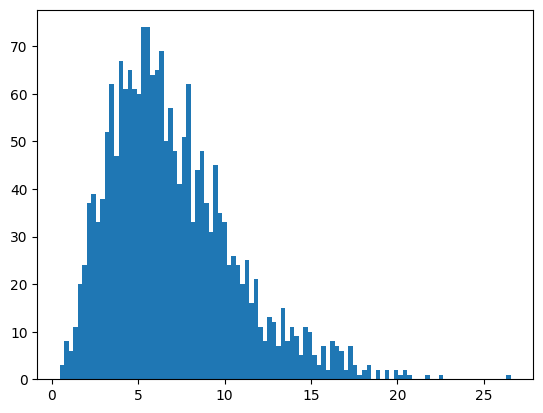

In [1]:
import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(seed=42)
m = 2000  # number of instances

boylar = rng.normal(175, 10, size=(m,1))
yashlar = rng.uniform(18, 60, size=(m,1))
# maashlar = rng.exponential(scale=4, size=(m,1))
# maashlar = rng.chisquare(df=6, size=(m,1))
maashlar = rng.gamma(shape=3.5, scale=2, size=(m,1))

plt.hist(maashlar, bins=100)
plt.show()

In [2]:
from sklearn.preprocessing import add_dummy_feature

X = np.hstack([boylar/100, yashlar/100])
X_b = add_dummy_feature(X)
# X_b = np.c_[X, np.ones((m, 1))]

y = maashlar/10

X_b, y

(array([[1.        , 1.78047171, 0.19778537],
        [1.        , 1.64600159, 0.36687386],
        [1.        , 1.82504512, 0.40973487],
        ...,
        [1.        , 1.740846  , 0.23681841],
        [1.        , 1.69691782, 0.56835309],
        [1.        , 1.97141526, 0.38183515]], shape=(2000, 3)),
 array([[0.61006609],
        [0.64261833],
        [0.39956131],
        ...,
        [0.39419609],
        [1.47388686],
        [0.21100565]], shape=(2000, 1)))

# Polynomial regression

In [5]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([1.78047171, 0.19778537])

In [10]:
print(X[0]**2)
print(X[0,0] * X[0,1])

[3.1700795  0.03911905]
0.35215125176088635


In [6]:
X_poly[0]

array([1.78047171, 0.19778537, 3.1700795 , 0.35215125, 0.03911905])

In [11]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([-0.94376432]),
 array([[ 1.33431752,  2.52745436, -0.22949869, -1.34978453, -0.30903274]]))

In [13]:
from sklearn.pipeline import Pipeline
full_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("lin_reg", LinearRegression()),
])

full_pipeline.fit(X, y)
full_pipeline["lin_reg"].intercept_, full_pipeline["lin_reg"].coef_

(array([-0.94376432]),
 array([[ 1.33431752,  2.52745436, -0.22949869, -1.34978453, -0.30903274]]))

In [14]:
# good approach of using polynomial features
# num_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("poly", PolynomialFeatures(degree=2, include_bias=False)),
#     ("scaler", StandardScaler())
# ])

# bad but still acceptable approach of using polynomial features
# full_pipeline = Pipeline([
#     ("cleaning", preprocess),
#     ("poly", PolynomialFeatures(degree=2, include_bias=False)),
#     ("model", LinearRegression())
# ])

# Regularized Regression

Ridge and Lasso add a penalty term to the cost function to prevent overfitting, especially when dealing with:
- Many features relative to training instances
- Multicollinearity (correlated features)
- Noisy training data


## Ridge Regression

$$J(\theta) = \frac{1}{m} \|X\theta - y\|^2 + \alpha \|\theta\|_2^2$$

$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2$$

Where:
- $\alpha$ (alpha) is the **regularization hyperparameter** controlling the strength of regularization
   - $\alpha = 0$: No regularization (standard linear regression)
   - Large $\alpha$: Strong regularization (weights approach zero)
- $\theta_i$ are the model weights (excluding the bias term $\theta_0$)
- The bias term is **not regularized**

**Closed-Form Solution (Normal Equation):**

$$\hat{\theta} = (X^T X + \alpha A)^{-1} X^T y$$

Where $A$ is an $(n+1) \times (n+1)$ matrix with zeros everywhere except the bottom-right $n \times n$ submatrix (the bias term is not regularized):

$$A = \begin{pmatrix} 0 & 0 & \cdots & 0 \\ 0 & 1 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & 1 \end{pmatrix}$$

**Gradient for Gradient Descent:**

$$\nabla J(\theta) = \frac{2}{m} X^T(X\theta - y) + 2\alpha \theta$$

In [ ]:
from sklearn.linear_model import Ridge

ridge_r = Ridge(alpha=1)
ridge_r.fit(X, y)
ridge_r.intercept_, ridge_r.coef_


## Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) uses an **ℓ₁ penalty**:

$$J(\theta) = \frac{1}{m} \|X\theta - y\|^2 + \alpha \|\theta\|_1$$

$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|$$

- **Feature Selection**: Lasso tends to produce **sparse models** - it drives some weights to **exactly zero**, effectively performing automatic feature selection
- **Interpretability**: Useful when you suspect only a few features actually matter
- **When to use**: Prefer Lasso when you want feature selection or have many irrelevant features

**Subgradient for Gradient Descent:**

The ℓ₁ penalty is not differentiable at $\theta_i = 0$, so we use the **subgradient**:

$$\nabla J(\theta) = \frac{2}{m} X^T(X\theta - y) + \alpha \cdot \text{sign}(\theta)$$

Where $\text{sign}(\theta_j)$ is:
- $+1$ if $\theta_j > 0$
- $-1$ if $\theta_j < 0$
- $[-1, 1]$ if $\theta_j = 0$


In [ ]:
from sklearn.linear_model import Lasso

lasso_r = Lasso(alpha=0.1)
lasso_r.fit(X, y)
lasso_r.intercept_, lasso_r.coef_

# ElasticNet


$$
\begin{align*}
J(\theta) &= \text{MSE}(\theta) + \lambda_{1} \|\theta\|_1 + \lambda_{2} \|\theta\|_2^2 \\
&= \text{MSE}(\theta) + \lambda_{1} \sum_{i=1}^{n} |\theta_i| + \lambda_{2} \sum_{i=1}^{n} |\theta_i|^2
\end{align*}
$$

$$\nabla J(\theta) = \frac{2}{m} X^T(X\theta - y) + \lambda_{1}\text{sign}(\theta) + 2 \lambda_{2} \theta$$

In [ ]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X, y)
elastic.intercept_, elastic.coef_

$$
\frac{1}{2 n_{\rm samples}} \cdot \|y - X w\|_2^2
    + \alpha \cdot {\rm l1\_{ratio}} \cdot \|w\|_1
    + 0.5 \cdot \alpha \cdot (1 - {\rm l1\_{ratio}}) \cdot \|w\|_2^2
$$

$$
    a \cdot \|w\|_1 + 0.5 \cdot b \cdot \|w\|_2^2
$$

$$
    \alpha = a + b, \quad {\rm l1\_{ratio}} = \frac{a}{a + b}
$$